# Imports

In [5]:
!cd ../ && bash env.sh 

bash: env.sh: No such file or directory


In [6]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys 
import scanpy as sc
import warnings
import scanpy as sc
import anndata as ad
import os
from scipy.sparse import issparse
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
plt.rcParams["font.family"] = "Arial"
main_dir = '../'
# task_grn_inference_dir = '../../'
output_dir = f"{main_dir}/output/"

# - local imports 
from hiara import retrieve_feature_data, retrieve_sig_stats

from hiara import PRIOR_DIR, PLOTS_DIR, CLOCKS_DIR,  CELL_TYPES, surrogate_names, colors_blind, palette_cell_types, palette_datasets, palette_datasets_pretty, palette_genders, AGING_COHORTS
from hiara import retrieve_adata, retrieve_net, retrieve_net_consensus
from hiara import clock_version, use_local_clocks
from grn_benchmark.src.helper import load_env
env = load_env()
TASK_GRN_INFERENCE_DIR = env['TASK_GRN_INFERENCE_DIR']
to_save = f'{PLOTS_DIR}/umap/'
os.makedirs(to_save, exist_ok=True)

# Aging clock feature analysis

## stats

In [3]:
features_dict = {}
for cell_type in CELL_TYPES:
    net = retrieve_net_consensus(cell_type=cell_type)
    print(cell_type, net.shape)
    features_dict[cell_type] = net['target'].unique().tolist()

Retrieving consensus GRN for CD4T with min degree 3
CD4T (4631, 3)
Retrieving consensus GRN for CD8T with min degree 3
CD8T (14253, 3)
Retrieving consensus GRN for NK with min degree 3
NK (2466, 3)
Retrieving consensus GRN for B with min degree 3
B (8436, 3)
Retrieving consensus GRN for MONO with min degree 3
MONO (28272, 3)


['MONO', 'B', 'CD8T', 'CD4T', 'NK']


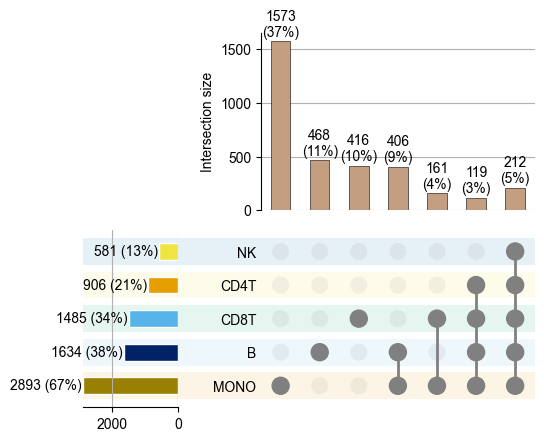

In [4]:
from grn_benchmark.src.exp_analysis.helper import plot_interactions, create_interaction_df

interaction_main_df = create_interaction_df(features_dict)
aa = plot_interactions(interaction_main_df, min_subset_size=100, min_degree=1, color_map=palette_cell_types)

plt.savefig(f'{PLOTS_DIR}/interactions_targets.png', dpi=300, transparent=True, bbox_inches='tight')
# plt.title(surrogate_names[race], pad=40, fontsize=10, fontweight='bold')

## gsea

In [10]:
import gseapy as gp
from gseapy import barplot, dotplot
all_genes = np.loadtxt(f'{PRIOR_DIR}/gene_names.txt', dtype=str)
print(all_genes)
gene_sets = 'MSigDB_Hallmark_2020'
res2d_store = []
for cell_type, genes in features_dict.items():
    rr = gp.enrichr(gene_list=list(genes),
                gene_sets=gene_sets, #, 'KEGG_2021_Human'
                organism='human', 
                outdir=None, 
                cutoff=1,
                # background=list(all_genes),
                )
    res2d = rr.res2d
    res2d.rename(columns={'Adjusted P-value': 'FDR'}, inplace=True)
    filter_col = 'FDR' #'FDR q-val'
    res2d = res2d[res2d[filter_col]<0.05]
    if res2d.shape[0] == 0:
        continue
    print(res2d.shape)
    res2d['cell_type'] = cell_type
    res2d_store.append(res2d)

pathway_scores = pd.concat(res2d_store)

pathway_scores['n_genes'] = pathway_scores['Genes'].str.split(';').apply(len)
pathway_scores["neg_log10_adj_pval"] = -np.log10(pathway_scores["FDR"])

['DDX11L16' 'DDX11L1' 'WASH7P' ... 'ENSG00000149656' 'ENSG00000310230'
 'IQSEC3P3']
(33, 10)
(32, 10)
(28, 10)
(36, 10)
(32, 10)


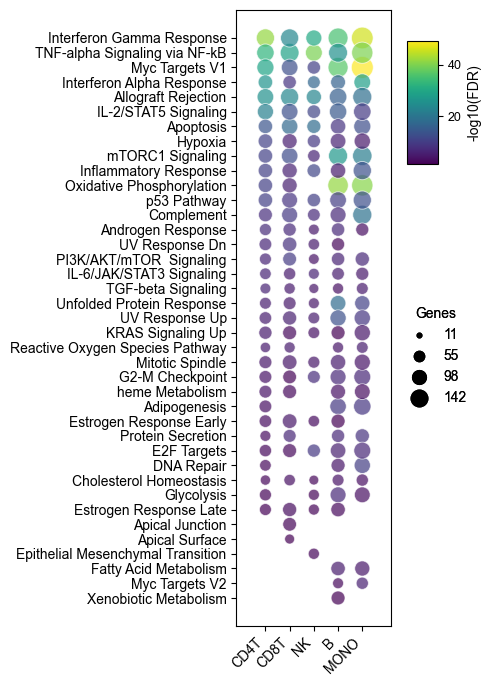

In [12]:
from ciim.src.feature_association.plots import dotplot_category_color
from ciim.src.config import surrogate_names
    
fig, ax = plt.subplots(1, 1, figsize=(2, 8), sharey=True, sharex=True)

pathway_scores['cell_type'] = pd.Categorical(pathway_scores['cell_type'], categories=CELL_TYPES, ordered=True)
show_color_legend = True
show_size_legend = True

dotplot_category_color(pathway_scores, 
            ax, 
            color_col='neg_log10_adj_pval', 
            size_col='n_genes', 
            x='cell_type', 
            y='Term', 
            palette='viridis', 
            sizes=(50, 250),
            show_color_legend=show_color_legend, 
            show_size_legend=show_size_legend,
            size_legend_title='Genes',
            color_legend_title='-log10(FDR)',
            color_legend_loc=(1.1, 0.75),
            size_legend_loc=(1.05, 0.35),
            size_legend_scale=1,
            y_label='',
            alpha=0.7)
plt.savefig(f'{PLOTS_DIR}/enrichment_targets.png', dpi=300, transparent=True, bbox_inches='tight')

## TF activity

In [7]:
from grnimmuneclock import retrieve_function
top_genes_dict = {}
top_weights_dict = {}
top_tfs_dict = {}
top_acts_dict = {}
for cell_type in CELL_TYPES:
    model, gene_names = retrieve_function(cell_type=cell_type, use_local_clocks=use_local_clocks, output_dir=CLOCKS_DIR, version=clock_version)
    coefs = model.named_steps["ridge"].coef_
    
    abs_coefs = np.abs(coefs)
    top_idx = np.argsort(abs_coefs)[-5:][::-1]
    top_genes = [gene_names[i] for i in top_idx]
    top_genes_dict[cell_type] = top_genes
    top_weights_dict[cell_type] = coefs[top_idx]

    if True: # calculate TF activity
        import decoupler as dc
        net = retrieve_net_consensus(cell_type=cell_type)
        
        if True: # select top genes
            top_idx = np.argsort(abs_coefs)[-100:][::-1]
            top_genes = [gene_names[i] for i in top_idx]
            gene_names = top_genes
            coefs = coefs[top_idx]
        obs = pd.DataFrame({'sample': [1]})
        var = pd.DataFrame({'genes': gene_names})
        var.index = var['genes']

        X=[[float(c) for c in coefs]]
        adata = ad.AnnData(np.asarray(X), obs=obs, var=var)
        dc.mt.ulm(adata, net, tmin=5)
        tf_acts_df = adata.obsm['score_ulm']
        tf_acts_X = tf_acts_df.values[0]

        abs_acts = np.abs(tf_acts_X)
        tfs = tf_acts_df.columns
        top_idx = np.argsort(abs_acts)[-5:][::-1]
        top_tfs= [tfs[i] for i in top_idx]
 
        top_tfs_dict[cell_type] = top_tfs
        top_acts_dict[cell_type] = tf_acts_X[top_idx]

CD4T
CD8T
NK
B
MONO
CD4T
CD8T
NK
B
MONO


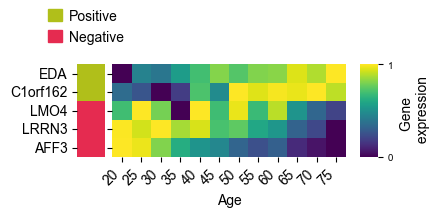

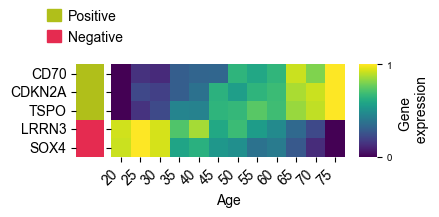

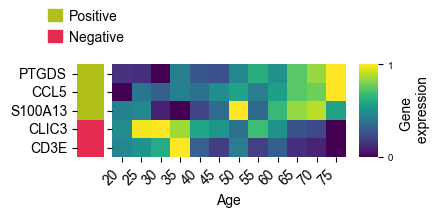

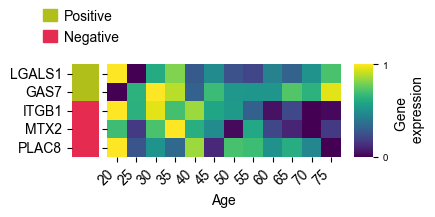

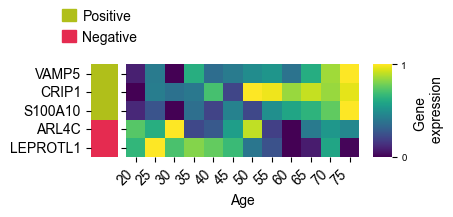

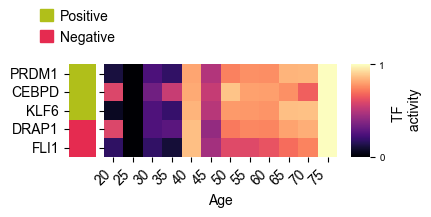

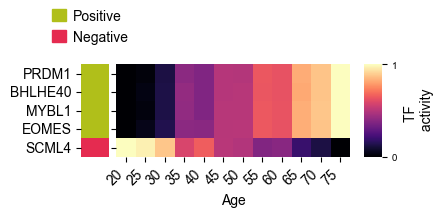

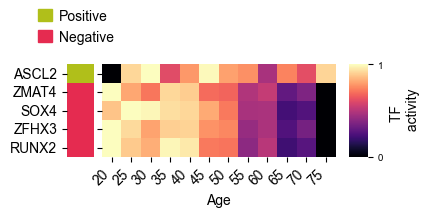

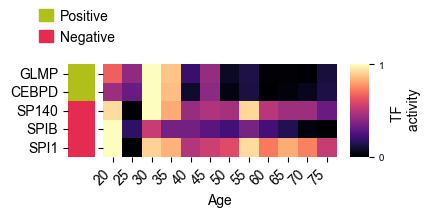

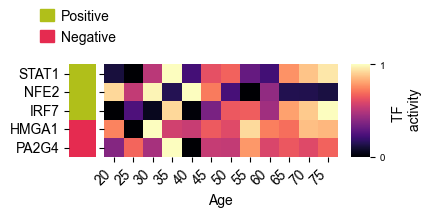

In [17]:
def plot_feature_values(cell_type, features, feature_type, dataset='data1', ax=None, show_cbar=True, data_type='bulk', 
                                    age_limit=[20, 80], show_ylabels=True):
    from hiara.src.feature_association.helper import retrieve_feature_data, bin_feature_values
    from hiara.src.feature_association.plots import heatplot_age_trend
       
    adata = retrieve_feature_data(dataset=dataset, cell_type=cell_type, data_type=data_type, feature_type=feature_type) 
    adata = adata[(adata.obs['age'] > age_limit[0]) & (adata.obs['age'] < age_limit[1])]
    adata = adata[:, adata.var_names.isin(features)]
    assert adata.shape[1]>0, f"Features {features} not found in dataset {dataset} for cell type {cell_type}"

    mean_expr = bin_feature_values(adata)
    # sort the index base on features
    mean_expr = mean_expr.loc[features]
    ages = sorted(mean_expr.columns)
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 2))

    heatplot_age_trend(mean_expr[ages], cmap='magma' if feature_type=='tf_activity' else 'viridis', 
                        cbar_title = "Gene \n expression" if feature_type == 'gene_expression' else (
                                    "TF \n activity" if feature_type == 'tf_activity' else "Gene score"
                                ),
                        ax=ax, 
                        show_cbar=show_cbar,
                        cbar_kws={
                            "shrink": 1,
                            "aspect": 5,       # Lower values = thicker colorbar (default is ~20)
                            "fraction": 0.1    # Controls the width space the cbar takes in the figure
                        })
    if not show_ylabels:
        ax.set_yticklabels([])
    ax.set_ylabel('')
    ax.set_xlabel('Age')
from matplotlib.colors import ListedColormap

def wrapper_trend(top_features_dict, top_feature_values_dict, feature_type, dataset=AGING_COHORTS[0]):
    from matplotlib import patches as mpatches
    for cell_type, features in top_features_dict.items():
        print(cell_type)
        fig, axes = plt.subplots(1, 2, figsize=(4, 1.2), width_ratios=[.1, 1], gridspec_kw={'wspace':0.05})
        # --- Left: weight sign heatmap ---
        ax = axes[0]
        top_weights = np.sign(top_feature_values_dict[cell_type])  # ±1
        df = pd.DataFrame({'feature': features, 'weight': top_weights})
        df = df.set_index('feature').loc[features]  # enforce order
        # sort df based on sign
        df = df.sort_values(by='weight', ascending=False)
        features = df.index.tolist()
        cmap = ListedColormap(['#E52B50', '#B0BF1A'])
        sns.heatmap(
            df[['weight']],
            cmap=cmap,
            cbar=False,
            ax=ax,
            annot=False )
        ax.set_xlabel("")
        red_patch = mpatches.Patch(color='#E52B50', label='Negative')
        green_patch = mpatches.Patch(color='#B0BF1A', label='Positive')
        ax.legend(handles=[green_patch, red_patch], bbox_to_anchor=(1.7, 1.6), loc='upper right', borderaxespad=0., frameon=False)
        ax.set_ylabel('')
        ax.set_xlabel('')
        ax.set_xticks([])

        ax = axes[1]

        plot_feature_values(cell_type, features, feature_type=feature_type, dataset=dataset, ax=ax, show_cbar=True,data_type='bulk', 
                                        age_limit=[20, 80], show_ylabels=True)
        ax.set_yticklabels([])
        # plt.title(f'{cell_type}', pad=15, weight='bold')
wrapper_trend(top_genes_dict, top_weights_dict, feature_type='gene_expression', dataset=AGING_COHORTS[0])
# plt.savefig(f'{PLOTS_DIR}/top_genes_{cell_type}.png', dpi=300, transparent=True, bbox_inches='tight')
wrapper_trend(top_tfs_dict, top_acts_dict, feature_type='tf_activity', dataset=AGING_COHORTS[0])

# TF activity trend vs expression trend in aging

In [53]:
from ciim.src.feature_association.plots import plot_activation_vs_expression

cell_type = 'CD8T'
os.makedirs(PLOTS_DIR, exist_ok=True)
stats_tfs = retrieve_sig_stats()
stats_targets = retrieve_sig_stats(feature_type='gene_expression')
stats_all = stats_tfs[['cell_type', 'tf', 'slope', 'p_value_adj', 'dataset']].merge(
    stats_targets[['cell_type', 'target', 'slope', 'p_value_adj', 'dataset']],
    left_on=['cell_type', 'tf', 'dataset'],
    right_on=['cell_type', 'target', 'dataset'],
    how='inner',
    suffixes=('_source', '_target')
)
stats_all = stats_all[stats_all['dataset'].isin(['data1'])]
stats_all['Activation significance'] = np.sign(stats_all['slope_source']) * -np.log10(stats_all['p_value_adj_source'].clip(lower=1e-300))
stats_all['Expression significance'] = np.sign(stats_all['slope_target']) * -np.log10(stats_all['p_value_adj_target'].clip(lower=1e-300))
df = stats_all[stats_all['cell_type'] == cell_type].copy()
plot_activation_vs_expression(df, col_x = 'Expression significance', 
                                  col_y = 'Activation significance', 
                                  y_label='Activation significance \n (-log10padj)', 
                                  x_label='Expression significance \n (-log10padj)', figsize=(3, 2.7))
plt.legend([],[], frameon=False)                               
plt.suptitle(f"TF activation vs expression ({cell_type})", y=.95, fontsize=12, weight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/activation_vs_expression.png', dpi=300)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/jno24/Documents/projs/ongoing/hiara/base_folder/output//features//gene_expression/stats/stats_multi_cohort_bulk.csv'

# Trajectory plot: TF acitvity with age


In [ ]:

from ciim.src.feature_association.plots import plot_trends
from ciim.src.config import palette_datasets, datasets_e
if True:
    datasets = datasets_e
    # # - load data
    if True:
        cell_type = 'CD8T'
        adata_complete = {dataset: retrieve_adata(dataset) for dataset in datasets}
        adata_dict = {dataset: adata[adata.obs['cell_type'] == cell_type] for dataset, adata in adata_complete.items()}
        nets_dict = {dataset: retrieve_net(dataset, cell_type) for dataset in datasets}
        tf_acts_dict = {}
        for dataset in datasets:
            tf_acts = calculate_tf_activity(adata_dict[dataset], nets_dict[dataset])
            print(tf_acts.shape)
            tf_acts_dict[surrogate_names[dataset]] = tf_acts

    cell_type = 'CD8T'
    genes = ['KLF6']
    
    plot_trends(top_tfs=genes, datasets=[surrogate_names[d] for d in datasets], data_dict=tf_acts_dict, palette=palette_datasets_pretty, cell_type=cell_type, surrogate_names=surrogate_names)
    plt.yticks([])
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/tf_activity/trends_{cell_type}_case.png', dpi=300)

# Compare bulk vs sc GRNs

In [42]:
if True:
    net_store = []
    for data_type in ['sc', 'bulk']:
        for cell_type in CELL_TYPES:
            for dataset in DISCOVERY_COHORTS:
                net = retrieve_net(dataset, cell_type, data_type=data_type)
                net['edge'] = net['source'] + '_' + net['target']
                net['cell_type'] = cell_type
                net['dataset'] = dataset
                net['data_type'] = data_type
                net_store.append(net)
    nets_all = pd.concat(net_store)


TFs in sc vs bulk: 203 424
TFs in sc vs bulk: 177 337
TFs in sc vs bulk: 99 468
TFs in sc vs bulk: 304 442
TFs in sc vs bulk: 344 682


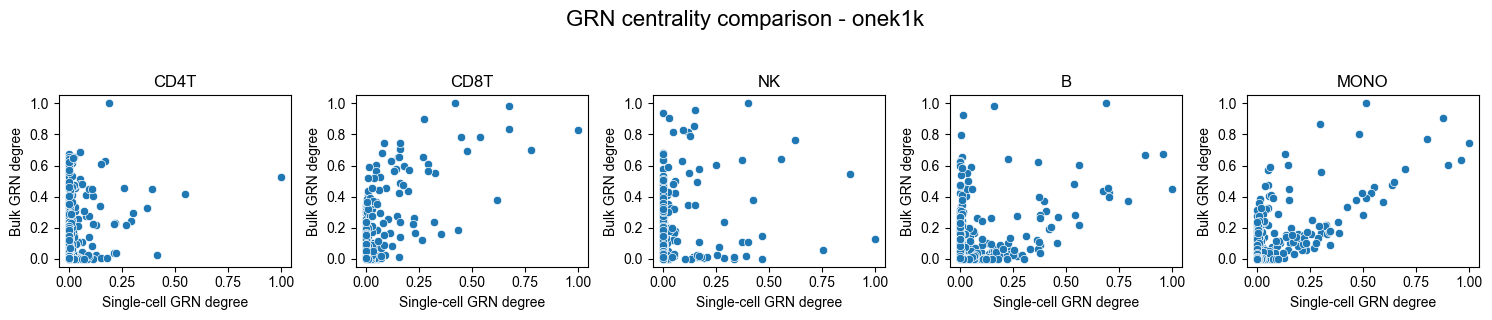

TFs in sc vs bulk: 363 424
TFs in sc vs bulk: 396 399
TFs in sc vs bulk: 270 394
TFs in sc vs bulk: 409 387
TFs in sc vs bulk: 425 322


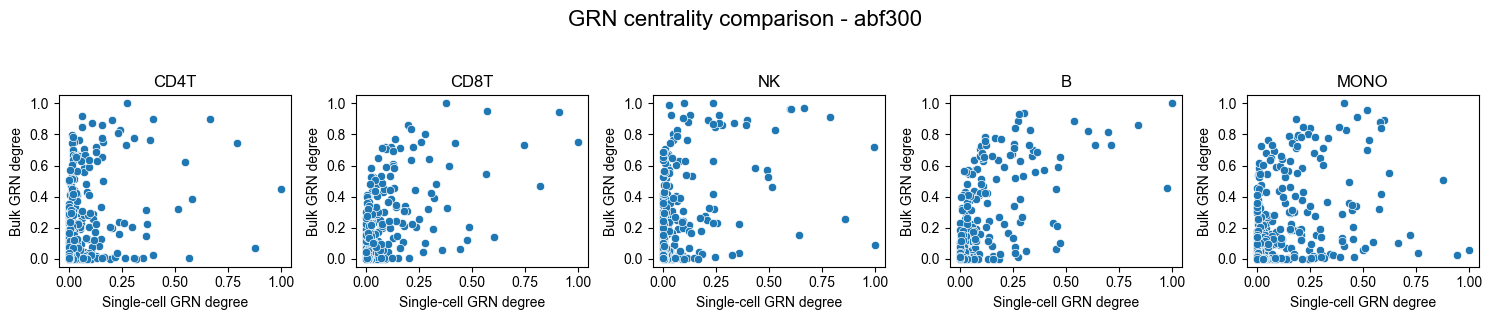

TFs in sc vs bulk: 434 445
TFs in sc vs bulk: 483 481
TFs in sc vs bulk: 392 392
TFs in sc vs bulk: 520 422
TFs in sc vs bulk: 510 449


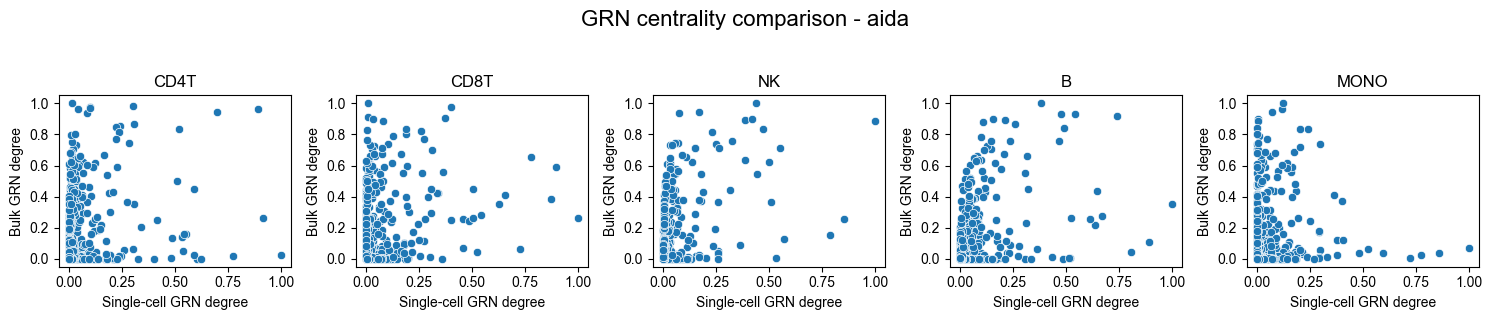

TFs in sc vs bulk: 289 437
TFs in sc vs bulk: 213 438
TFs in sc vs bulk: 186 485
TFs in sc vs bulk: 250 477
TFs in sc vs bulk: 272 481


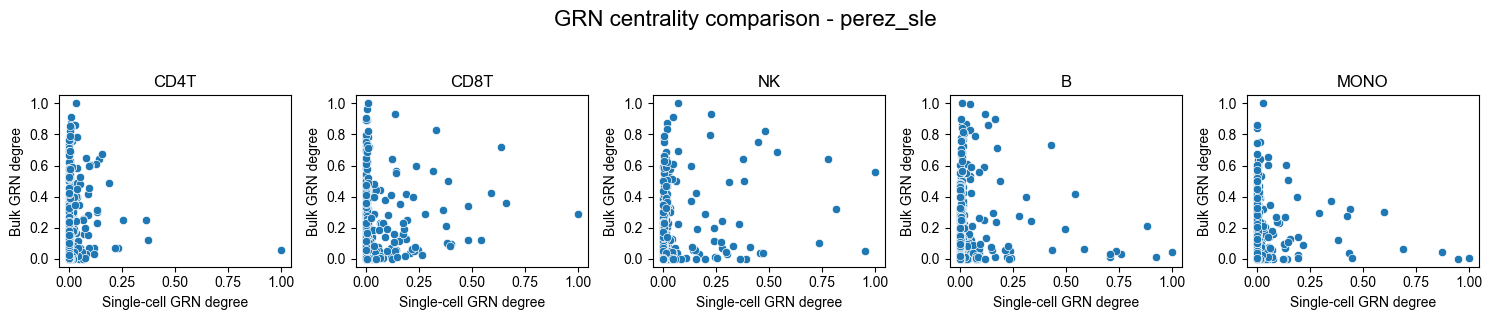

In [51]:
# - compare centrality
for dataset in nets_all['dataset'].unique():
    fig, axes = plt.subplots(1, len(nets_all['cell_type'].unique()), figsize=(3*len(nets_all['cell_type'].unique()),3))
    for i, cell_type in enumerate(nets_all['cell_type'].unique()):
        net_sc = nets_all[(nets_all['data_type']=='sc') & (nets_all['dataset']==dataset) & (nets_all['cell_type']==cell_type)]
        net_bulk = nets_all[(nets_all['data_type']=='bulk') & (nets_all['dataset']==dataset) & (nets_all['cell_type']==cell_type)]

        # print('TFs in sc vs bulk:', net_sc['source'].nunique(), net_bulk['source'].nunique())
        c_sc = net_sc.groupby('source').size()
        c_bulk = net_bulk.groupby('source').size()

        c_sc = c_sc/c_sc.max()
        c_bulk = c_bulk/c_bulk.max()

        c_sc = c_sc.reset_index().rename(columns={0:'degree_sc'})
        c_bulk = c_bulk.reset_index().rename(columns={0:'degree_bulk'})
        c_all = c_sc.merge(c_bulk, on='source', how='outer').fillna(0)
        
        sns.scatterplot(data=c_all, x='degree_sc', y='degree_bulk', ax=axes[i])
        # plt.xscale('log')
        # plt.yscale('log')
        axes[i].set_xlabel('Single-cell GRN degree')
        axes[i].set_ylabel('Bulk GRN degree')
        axes[i].set_title(f'{cell_type}')
    plt.suptitle(f'GRN centrality comparison - {dataset}', y=1.05, fontsize=16)
    plt.tight_layout()
    plt.show()
    

# Promotor-based GRNs

In [12]:
# Run full GRN analysis
!cd ../ && python src/feature_association/script.py

# Run promotor-only GRN analysis
!cd ../ && python src/feature_association/script.py --promotor-only

{'type': 'bulk', 'feature_type': 'tf_activity', 'cell_types': ['CD4T', 'CD8T', 'NK', 'B', 'MONO'], 'datasets': ['data1', 'data7_allTPs_jalil', 'data12', 'SLE_European', 'data13_Korean', 'data13_Japanese'], 'association_type': 'spearman', 'cell_type_resolution': 'Major_CT', 'stats_features': '/Users/jno24/Documents/projs/ongoing/hiara/base_folder/output//tf_activity/stats_features_bulk.csv', 'stats_all': '/Users/jno24/Documents/projs/ongoing/hiara/base_folder/output//tf_activity/stats_all_bulk.csv', 'temp_dir': '/Users/jno24/Documents/projs/ongoing/hiara/base_folder/output//tmp/', 'only_promotor_based': False, 'gene_coverage': None}
Calculating TF activity...
Loading data...
Calculating TF activity...
  - Promotor-based only: False
data1 bulk
cell types:   0%|                                         | 0/5 [00:00<?, ?it/s]... storing 'dataset' as categorical
... storing 'condition' as categorical
cell types:  20%|██████▌                          | 1/5 [00:07<00:29,  7.26s/it]... storing 

In [29]:
# Compare promotor-only vs full GRN results
!cd ../ && python src/experiments/compare_promotor_vs_full.py

PROMOTOR-BASED GRN COMPARISON ANALYSIS

Loading statistics...
  - Full GRN stats: 6356 rows
  - Promotor-only stats: 3281 rows

Running comparisons...

  Cell type: CD4T
    Full GRN: 75 significant TFs
    Promotor-only: 30 significant TFs
    Overlap: 30 TFs (40.0%)
    Jaccard index: 0.400
Saved Venn diagram to /Users/jno24/Documents/projs/ongoing/hiara/base_folder/output//plots//promotor_comparison/venn_CD4T.png
Saved correlation plot to /Users/jno24/Documents/projs/ongoing/hiara/base_folder/output//plots//promotor_comparison/correlation_CD4T.png
    Effect size correlation (Spearman): ρ=0.951

  Cell type: CD8T
    Full GRN: 227 significant TFs
    Promotor-only: 114 significant TFs
    Overlap: 114 TFs (50.2%)
    Jaccard index: 0.502
Saved Venn diagram to /Users/jno24/Documents/projs/ongoing/hiara/base_folder/output//plots//promotor_comparison/venn_CD8T.png
Saved correlation plot to /Users/jno24/Documents/projs/ongoing/hiara/base_folder/output//plots//promotor_comparison/correla

# UMAP

In [14]:
dataset = 'soundlife'
adata = retrieve_adata(dataset=dataset)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.pp.pca(adata, use_highly_variable=True)  
sc.pp.neighbors(adata, n_neighbors=15)  
sc.tl.umap(adata) 


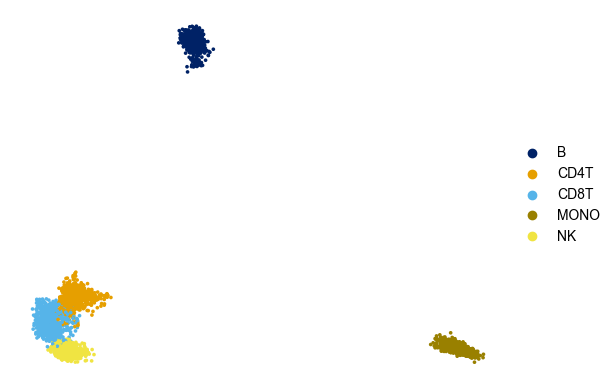

In [15]:
sc.pl.pca(adata, color='Major_CT', palette=palette_cell_types, title='', frameon=False)

# Datasets stats

In [46]:
from ciim.src.config import DISCOVERY_COHORTS, ALL_DATASETS, AGING_COHORTS
data_store = []
for dataset in AGING_COHORTS:
    adata = retrieve_adata(dataset, condition=None)
    
    for condition in adata.obs['condition'].unique():
        obs = adata[adata.obs['condition'] == condition].obs
        n_cells = obs['cell_count'].sum()
        n_donors = obs['donor_id'].nunique()
        n_age_donors = obs['donor_age'].nunique()
        if condition == 'healthy':
            condition = '-'
        data_store.append({'Cohort': dataset, 'Donors': n_donors, 'Cells': n_cells, 'Genes': adata.n_vars, 'Disease': condition})
    
df = pd.DataFrame(data_store)
df['Cohort'] = df['Cohort'].map(surrogate_names)
df.sort_values('Disease')

,Cohort,Donors,Cells,Genes,Disease
0,OneK1K,976,1233944,9100,-
1,ABF300,166,1897189,13152,-
2,SoundLife,96,13189039,15123,-
3,AIDA,623,1229847,12064,-
5,Perez,99,473142,10537,-
4,Perez,162,758325,10537,SLE


In [ ]:
df['only_healthy'] = df['Disease'].isin(['-'])
df_healthy = df[df['only_healthy']]
df_healthy['Cells'].sum(), df_healthy['Donors'].sum()

      Cohort  Donors     Cells  Genes Disease  only_healthy
0     OneK1K     976   1233944   9100       -          True
1     ABF300     166   1897189  13152       -          True
2  SoundLife      96  13189039  15123       -          True
3       AIDA     623   1229847  12064       -          True
5      Perez      99    473142  10537       -          True


(18023161, 1960)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Saving to /vol/projects/jnourisa//output//plots//datasets_summary_Cells.png
Saving to /vol/projects/jnourisa//output//plots//datasets_summary_Donors.png


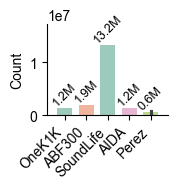

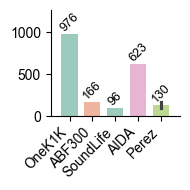

In [48]:
from ciim.src.config import palette_datasets

# Convert DataFrame to long format for easier plotting
df_long = df.melt(id_vars=["Cohort"], var_name="Metadata", value_name="Count")

cols = ['Cells', 'Donors']

for i, metadata in enumerate(cols):
    fig, ax = plt.subplots(1,1, figsize=(2, 2), sharex=False)
    # Create bar plot
    sns.barplot(data=df, x='Cohort', y=metadata, alpha=.7, ax=ax, hue='Cohort', width=.7, palette=palette_datasets_pretty, legend=False)
    # Annotate bars with values (rotated 45 degrees)
    for p in ax.patches:
        value = int(p.get_height())
        if value > 100000:
            value = f'{value/1e6:.1f}M'
        ax.text(p.get_x() + p.get_width() / 2,  # X position
                p.get_height(),  # Y position (top of bar)
                f'{value}',  # Text label
                ha='center', va='bottom', fontsize=9, rotation=45)  # Rotate 45 degrees

    # Formatting
    # ax.set_title(metadata, pad=20)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.margins(x=0.1, y=0.3)
    
    if i == 0:
        ax.set_ylabel("Count")
    else:
        ax.set_ylabel("")
    
    ax.set_xlabel("")
    ax.legend().remove()
    plt.tight_layout()

    plt.xticks(rotation=45)
    file_name = f'{PLOTS_DIR}/datasets_summary_{metadata}.png'
    print(f'Saving to {file_name}')
    plt.savefig(file_name, bbox_inches='tight', dpi=200, transparent=True)

# plt.show()

In [49]:
# - overall gender coverage
datasets = AGING_COHORTS
gender_samples = {}
combined_df = []

for dataset in datasets:
    adata = retrieve_adata(dataset)
    adata.obs['donor_age'] = adata.obs['donor_id'].astype(str) + '_' + adata.obs['age'].astype(str)
    df = adata.obs.copy()
    df['sex'] = df['sex'].apply(lambda name: {'F': 'Female', 'M': 'Male'}.get(name, name))
    df = df.drop_duplicates(subset=['donor_age'])
    df['dataset'] = dataset
    combined_df.append(df)

df = pd.concat(combined_df)

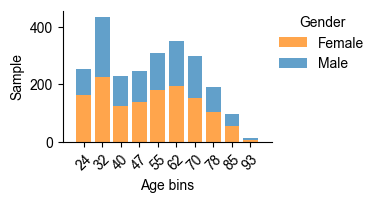

In [50]:
df['sex'] = df['sex'].apply(lambda name: {'F':'Female', 'M':'Male'}.get(name, name))
df = df.drop_duplicates(subset=['donor_age'])
df = df[df['age']>20]
# Count occurrences of each sex within each age group
df_count = df.groupby(['age', 'sex'])['donor_age'].nunique().reset_index(name='count')
# Pivot data for stacking
df_pivot = df_count.pivot(index='age', columns='sex', values='count').fillna(0)
# Plot stacked bar chart
df_pivot['binned'] = pd.cut(df_pivot.index, bins=10)  
df_binned = df_pivot.groupby('binned').sum() 
fig, ax = plt.subplots(figsize=(2.7, 1.7))
df_binned.plot(kind='bar', stacked=True, ax=ax, color=palette_genders, alpha=0.7, width=.8)


ax.set_xlabel("Age bins")
ax.set_ylabel("Sample")  
bin_midpoints = [int(interval.mid) for interval in df_binned.index.categories]
ax.set_xticklabels(bin_midpoints)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
x_min, x_max = ax.get_xlim()
ax.set_xlim(x_min - .5, x_max + .5) 
ax.legend(loc=[1.01, .5], frameon=False, title='Gender')
plt.savefig(f'{PLOTS_DIR}/datasets_age_distribution.png', bbox_inches='tight', dpi=300, transparent=True)


save to /vol/projects/jnourisa//output//plots//sex_distribution.png


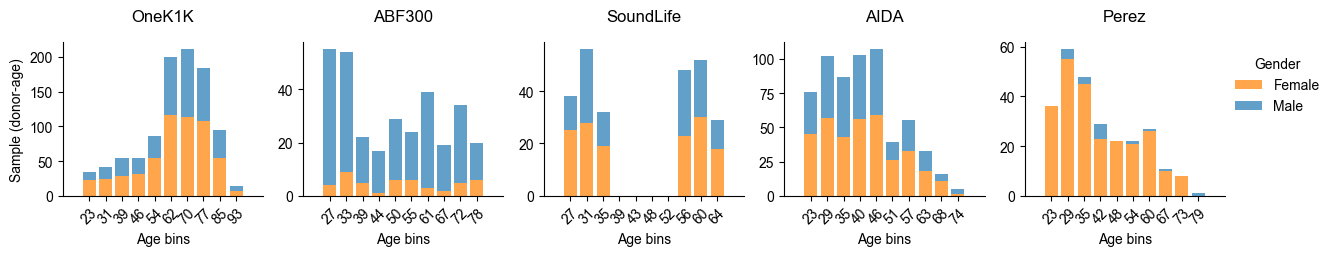

In [51]:
gender_samples = {}
def gender_distribution_plot(datasets):
    fig, axes = plt.subplots(1, len(datasets), figsize=(3*len(datasets), 2), sharey=False)
    for i, dataset in enumerate(datasets):
        adata = retrieve_adata(dataset)
        adata.obs['donor_age'] = adata.obs['donor_id'].astype(str) + '_' + adata.obs['age'].astype(str)
        
        df = adata.obs.copy()
        df['sex'] = df['sex'].apply(lambda name: {'F':'Female', 'M':'Male'}.get(name, name))
        df = df.drop_duplicates(subset=['donor_age'])

        # Count occurrences of each sex within each age group
        df_count = df.groupby(['age', 'sex'])['donor_age'].nunique().reset_index(name='count')
        gender_samples[dataset] = {sex: df_count[df_count['sex']==sex]['count'].sum() for sex in ['Male', 'Female']}

        # Pivot data for stacking
        df_pivot = df_count.pivot(index='age', columns='sex', values='count').fillna(0)

        # Plot stacked bar chart
        df_pivot['binned'] = pd.cut(df_pivot.index, bins=10)  
        df_binned = df_pivot.groupby('binned').sum() 
        df_binned.plot(kind='bar', stacked=True, ax=axes[i], color=palette_genders, alpha=0.7, width=.8)


        axes[i].set_xlabel("Age bins")
        axes[i].set_ylabel("Sample (donor-age)" if i == 0 else "")  
        axes[i].set_title(surrogate_names[dataset], pad=15)
        bin_midpoints = [int(interval.mid) for interval in df_binned.index.categories]
        axes[i].set_xticklabels(bin_midpoints)

        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        x_min, x_max = axes[i].get_xlim()
        axes[i].set_xlim(x_min - 1, x_max + 1) 
        
        axes[i].get_legend().remove()
    axes[i].legend(loc=(1.02, .5), frameon=False, title='Gender')
    file_name = f'{PLOTS_DIR}/sex_distribution.png'
    print('save to' , file_name)
    plt.savefig(file_name, dpi=200, bbox_inches='tight', transparent=True)
    plt.show()
gender_distribution_plot(datasets)

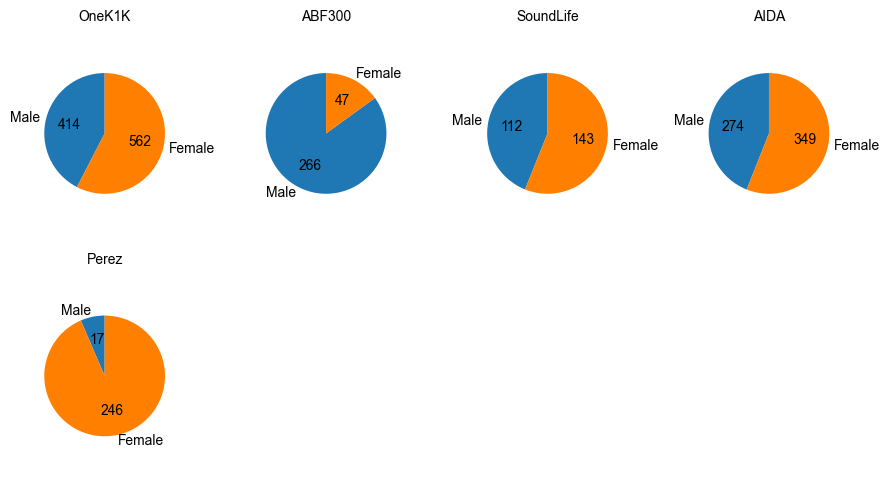

In [52]:
# Plotting pie charts
fig, axes = plt.subplots(2, 4, figsize=(9, 5))
axes = axes.flatten()

for i, (dataset, counts) in enumerate(gender_samples.items()):
    labels = list(counts.keys())
    sizes = list(counts.values())
    # axes[i].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=palette_genders.values())
    axes[i].pie(sizes, labels=labels, autopct=lambda p: f'{int(round(p * sum(sizes) / 100))}', startangle=90, colors=palette_genders.values())
    
    axes[i].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    axes[i].set_title(surrogate_names[dataset], fontsize=10, weight='bold')

# Hide any unused subplots
for j in range(len(gender_samples), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Ethnicity

In [55]:
# Collect data from all datasets once
dataset_race_data = []
all_races = set()

for dataset in AGING_COHORTS:
    adata = retrieve_adata(dataset)
    if 'race' not in adata.obs.columns:
        adata.obs['race'] = 'European'
    
    df = (
        adata.obs
        .groupby("race")["donor_id"]
        .nunique()
        .reset_index(name="count")
    )
    
    # Filter races that have at least 2% of the population
    total_donors = df['count'].sum()
    df['percentage'] = (df['count'] / total_donors) * 100
    df = df[df['percentage'] >= 2.0]
    df = df.drop(columns=['percentage'])
    
    if len(df) > 0:  # Only add if there are races meeting the threshold
        dataset_race_data.append((dataset, df))
        all_races.update(df['race'])

Saving to /vol/projects/jnourisa//output//plots//race_composition.png


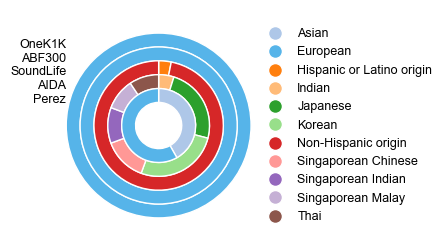

In [75]:

# Create figure with nested rings
fig, ax = plt.subplots(figsize=(4, 3))

# Map all unique races to distinct colors
all_races = sorted(all_races)
# Use a color palette with enough distinct colors
race_colors = {'European': colors_blind[1]}

color_palette = sns.color_palette("tab20", n_colors=len(all_races))
for race in all_races:
    if race in race_colors.keys():
        continue
    race_colors[race] = color_palette[len(race_colors)]


outer_radius = 1.0
ring_width = 0.15
dataset_labels = []

for i, (dataset, df) in enumerate(dataset_race_data):
    # Ensure colors match races correctly by sorting df by race to match color mapping
    df = df.sort_values('race')
    colors = [race_colors[r] for r in df["race"]]
    
    wedges, texts = ax.pie(
        df["count"],
        radius=outer_radius - i * ring_width,
        colors=colors,
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=ring_width, edgecolor="white", linewidth=1),
    )
    dataset_labels.append((surrogate_names[dataset], outer_radius - i * ring_width - ring_width/2))
ax.set(aspect="equal")
for dataset_name, radius in dataset_labels:
    ax.text(-1, radius - 0.05, dataset_name, 
            ha='right', va='center', fontsize=9, weight='bold')
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=race_colors[race], markersize=10)
    for race in all_races
]
ax.legend(
    handles,
    all_races,
    # title="Ethnici",
    loc="center left",
    bbox_to_anchor=(.9, 0.5),
    frameon=False,
    fontsize=9,
    labelspacing=0.5
)
# plt.tight_layout()
file_name = f'{PLOTS_DIR}/race_composition.png'
print(f'Saving to {file_name}')
plt.savefig(file_name, bbox_inches='tight', dpi=200, transparent=True)

## Disease

  condition  count
0   healthy     99
1       SLE    162
Saving to /vol/projects/jnourisa//output//plots//disease_composition_perez_sle.png


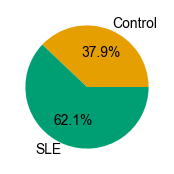

In [ ]:
dataset = 'perez_sle'
adata = retrieve_adata(dataset)
disease_info = adata.obs.groupby('condition')['donor_id'].nunique().reset_index(name='count')
print(disease_info)
fig, ax = plt.subplots(1, 1, figsize=(2, 2))
disease_info['condition'] = disease_info['condition'].replace({'healthy': 'Control'})
colors = {'Control': colors_blind[0], 'SLE': colors_blind[2]}
bb = ax.pie(disease_info['count'], labels=disease_info['condition'], autopct='%1.1f%%', colors=[colors[c] for c in disease_info['condition']], )
# plt.title(surrogate_names[dataset], pad=10)
file_name = f'{PLOTS_DIR}/disease_composition_{dataset}.png'
print(f'Saving to {file_name}')
plt.savefig(file_name, bbox_inches='tight', dpi=200, transparent=True)

Text(0.5, 1.0, 'C6: Covid')

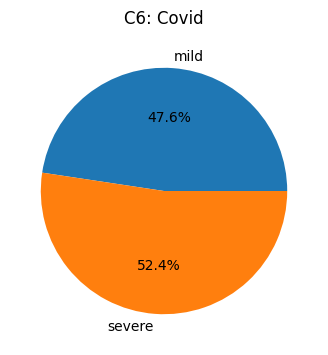

In [9]:
dataset = 'Covid_50MHH'
adata = retrieve_adata(dataset)

race_info = adata.obs.groupby('Max_WHO_Group')['donor_id'].nunique().reset_index(name='count')
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
bb = ax.pie(race_info['count'], labels=race_info['Max_WHO_Group'], autopct='%1.1f%%')
plt.title(surrogate_names[dataset], pad=10)

In [8]:
adata.obs.groupby(['cell_type', 'Max_WHO_Group']).size()

cell_type  Max_WHO_Group
B          mild             20
           severe           22
CD4T       mild             20
           severe           22
CD8T       mild             20
           severe           22
MONO       mild             20
           severe           22
NK         mild             20
           severe           22
dtype: int64

# GRNs

## Consensus nets

In [ ]:
net_store = []
for cell_type in CELL_TYPES:
    net = retrieve_net_consensus(cell_type=cell_type)
    

## Compare nets


In [ ]:

if True:
    net_store = []
    for cell_type in CELL_TYPES:
        for dataset in DISCOVERY_COHORTS:
            net = retrieve_net(dataset, cell_type)
            net['edge'] = net['source'] + '_' + net['target']
            net['cell_type'] = cell_type
            net['dataset'] = dataset
            print(f'net: {cell_type} {dataset} ', net.shape)
            net_store.append(net)
    nets_all = pd.concat(net_store)

net: CD4T onek1k  (8636, 6)
net: CD4T abf300  (18946, 6)
net: CD4T aida  (41919, 6)
net: CD4T perez_sle  (17400, 6)
net: CD8T onek1k  (12972, 6)
net: CD8T abf300  (47082, 6)
net: CD8T aida  (100000, 6)
net: CD8T perez_sle  (9455, 6)
net: NK onek1k  (2334, 6)
net: NK abf300  (11972, 6)
net: NK aida  (32625, 6)
net: NK perez_sle  (2879, 6)
net: B onek1k  (100000, 6)
net: B abf300  (36845, 6)
net: B aida  (74201, 6)
net: B perez_sle  (11578, 6)
net: MONO onek1k  (87343, 6)
net: MONO abf300  (71718, 6)
net: MONO aida  (100000, 6)
net: MONO perez_sle  (26143, 6)


['AIDA', 'ABF300', 'Perez', 'OneK1K']
['AIDA', 'ABF300', 'OneK1K', 'Perez']
['AIDA', 'ABF300', 'Perez', 'OneK1K']
['OneK1K', 'AIDA', 'ABF300', 'Perez']
['AIDA', 'OneK1K', 'ABF300', 'Perez']


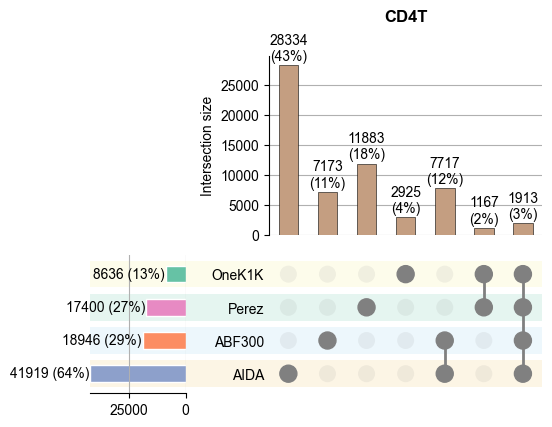

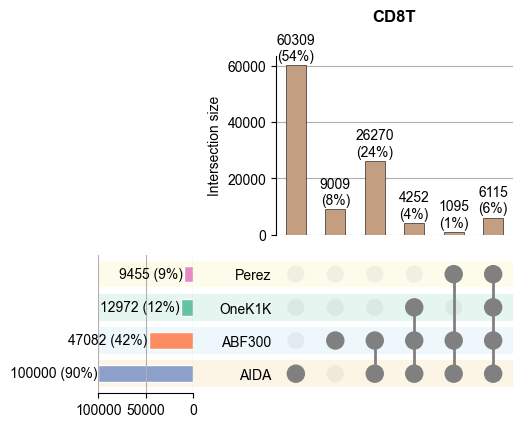

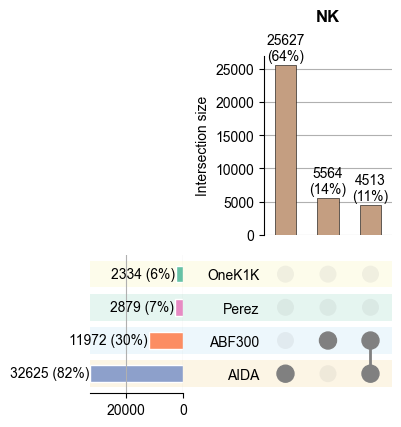

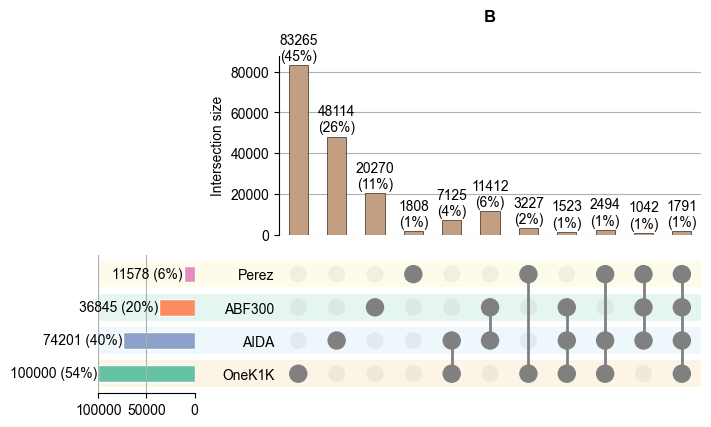

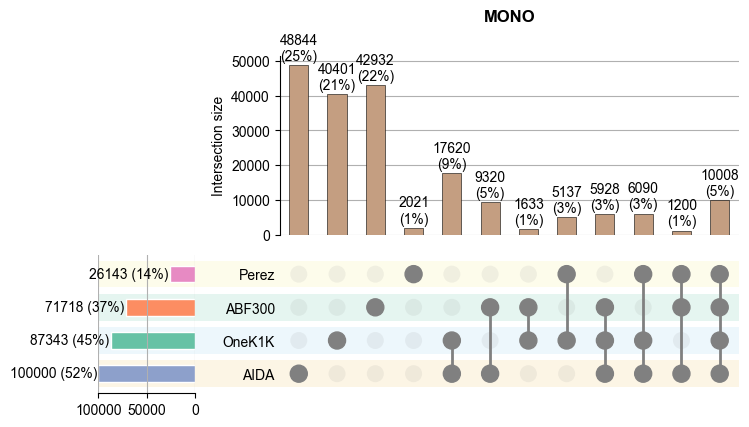

In [37]:
from grn_benchmark.src.exp_analysis.helper import plot_interactions, create_interaction_df
if True:
    to_show = 'edge'
    for cell_type in CELL_TYPES:
        if to_show=='source':
            min_subset_size=10
            min_degree=1
        if to_show=='target':
            min_subset_size=10
            min_degree=1
        if to_show=='edge':
            min_subset_size=1000
            min_degree=1

        nets = nets_all[nets_all['cell_type']==cell_type]
        df_dict = nets.groupby(['dataset'])[to_show].apply(list).to_dict()

        interaction_df = create_interaction_df(df_dict)
        interaction_df.columns = interaction_df.columns.map(surrogate_names)
        aa = plot_interactions(interaction_df, min_degree=min_degree, min_subset_size=min_subset_size, color_map=palette_datasets_pretty)
        plt.title(cell_type, y=1.15, weight='bold')